## Modelo XGBoost

Parte complementar do projeto Final da disciplina Aprend. de Máquina/PPgTI

### Preparação e carga de dados

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from pathlib import Path
import pandas as pd

sns.set_style('whitegrid')


In [30]:
# carregar o dataset normalizado gerado pelo checkpoint
data_path = Path('norm_df_metadadosPericias.csv')
if not data_path.exists():
    data_path = Path('/content/drive/MyDrive/Colab Notebooks/Doutorado/discAprendMáquina/[AprendMáquina] ProjetoFinal/norm_df_metadadosPericias.csv')

print(f'Carregando dataset normalizado de {data_path}')
df_norm = pd.read_csv(data_path)
print('Formato do dataset:', df_norm.shape)
print(df_norm['requer_pericia_count'].value_counts(normalize=True).rename('ratio'))

Carregando dataset normalizado de /content/drive/MyDrive/Colab Notebooks/Doutorado/discAprendMáquina/[AprendMáquina] ProjetoFinal/norm_df_metadadosPericias.csv
Formato do dataset: (165498, 17)
requer_pericia_count
1.0    0.50719
0.0    0.49281
Name: ratio, dtype: float64


In [31]:
df_norm.head()

,id_processo_judicial,in_tutela_antecipada_count,nm_juizado_count,ds_cidade_count,codigo_assunto_count,ds_assunto_judicial_count,ds_complemento_assunto_judicial_count,detalhe_assunto_1_count,detalhe_assunto_2_count,id_perito_count,ds_especialidade_count,ds_complemento_especialidade_count,ds_status_pericia_count,vara_count,triagem_peticao_count,label_especialidade_count,requer_pericia_count
0,0.974073,1.0,0.364363,0.116711,1.000000,1.000000,1.00000,1.000000,1.000000,0.004034,0.940182,0.267988,0.031846,0.123086,0.0,0.283492,1.0
1,0.512348,1.0,0.299115,0.080664,1.000000,1.000000,1.00000,0.356039,1.000000,0.009907,0.940182,0.120853,0.860855,0.087570,0.0,0.123303,1.0
2,0.178221,1.0,0.773330,0.344579,0.200864,0.200864,0.14681,0.318839,0.018163,1.000000,1.000000,1.000000,1.000000,0.349154,0.0,1.000000,0.0
3,0.576451,1.0,0.773330,0.344579,1.000000,1.000000,1.00000,1.000000,1.000000,0.034368,0.940182,0.267988,0.057866,0.349154,0.0,0.283492,1.0
4,0.697003,1.0,0.276221,0.068015,1.000000,1.000000,1.00000,1.000000,1.000000,0.010385,0.940182,0.120853,0.860855,0.074322,0.0,0.053155,1.0


### Organização de dados para treinamento, validação e testes

Numa primeira rodada de classificação as colunas ['ds_status_pericia_count', 'ds_especialidade_count', 'ds_complemento_especialidade_count', 'id_perito_count'] introduziram informações nas features que identificam as perícias realizadas ou não, e percebemos esses atributos fazem parte de dados que não estão disponíveis na fase anterior do processo, quando ainda se quer saber se será necessária a realização de perícias médicas.

Portanto, foram **removidas** do treinamento!

In [32]:
# preparar os dados para treino

feature_cols = [col for col in df_norm.columns
                if col not in ['requer_pericia_count', 'label_especialidade_count', 'id_processo_judicial', 'ds_status_pericia_count','ds_especialidade_count','ds_complemento_especialidade_count','id_perito_count']]
X = df_norm[feature_cols]
y = df_norm['requer_pericia_count'].astype(int)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=2 / 9, stratify=y_train_val, random_state=42, shuffle=True)

print('Divisão de dados:')
print('  treino:', X_train.shape)
print('  validação:', X_val.shape)
print('  teste:', X_test.shape)

Divisão de dados:
  treino: (115848, 10)
  validação: (33100, 10)
  teste: (16550, 10)


### Aplicação do XGBoost

In [41]:
from xgboost import XGBClassifier

# treinar o modelo XGBoost
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric=['logloss', 'error'],
    n_estimators=300, # 300
    learning_rate=0.05, # 0.05
    max_depth=6, # 6
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

# 'best_iteration' is only available when early stopping is used. Removed for now.
# print('Melhor iteração:', model.best_iteration)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=['logloss', 'error'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

### Resultados do XGBoost

In [42]:
# previsões e métricas

def compute_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
    }

for name, X_split, y_split in [
    ('Treino', X_train, y_train),
    ('Validação', X_val, y_val),
    ('Teste', X_test, y_test),
]:
    y_pred = model.predict(X_split)
    metrics = compute_metrics(y_split, y_pred)
    print(f'\n{name}')
    for metric_name, value in metrics.items():
        print(f'  {metric_name}: {value:.4f}')


Treino
  accuracy: 0.9183
  precision: 0.8979
  recall: 0.9465
  f1_score: 0.9215

Validação
  accuracy: 0.9170
  precision: 0.8961
  recall: 0.9460
  f1_score: 0.9204

Teste
  accuracy: 0.9171
  precision: 0.8965
  recall: 0.9458
  f1_score: 0.9205


In [43]:
# relatório detalhado no conjunto de teste

y_test_pred = model.predict(X_test)
print('Relatório de classificação (teste):')
print(classification_report(y_test, y_test_pred, digits=4))

Relatório de classificação (teste):
              precision    recall  f1-score   support

           0     0.9409    0.8876    0.9134      8156
           1     0.8965    0.9458    0.9205      8394

    accuracy                         0.9171     16550
   macro avg     0.9187    0.9167    0.9170     16550
weighted avg     0.9183    0.9171    0.9170     16550



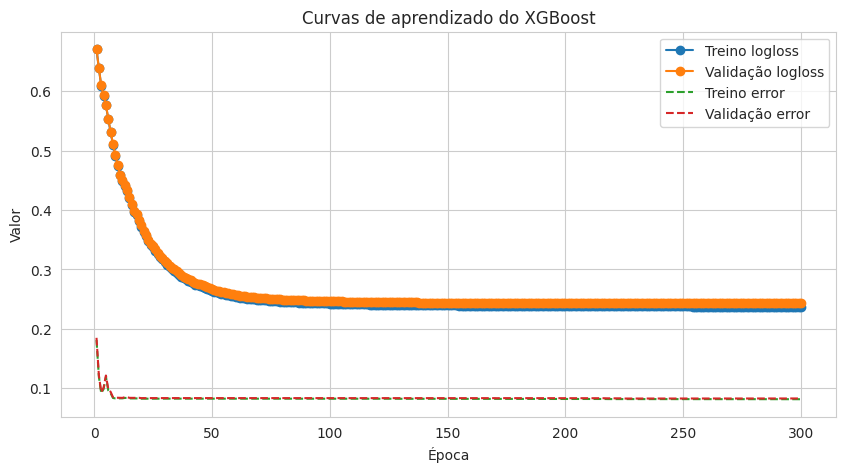

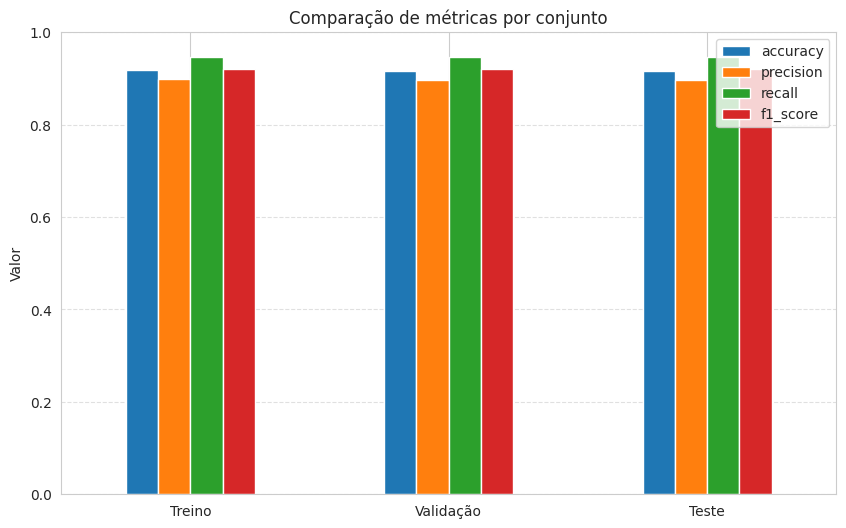

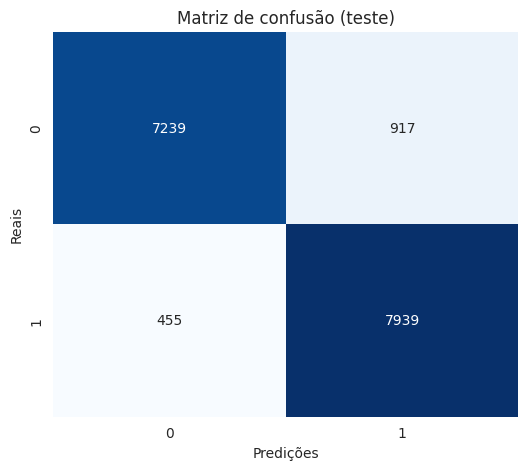

/tmp/ipykernel_2816/3922955280.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')


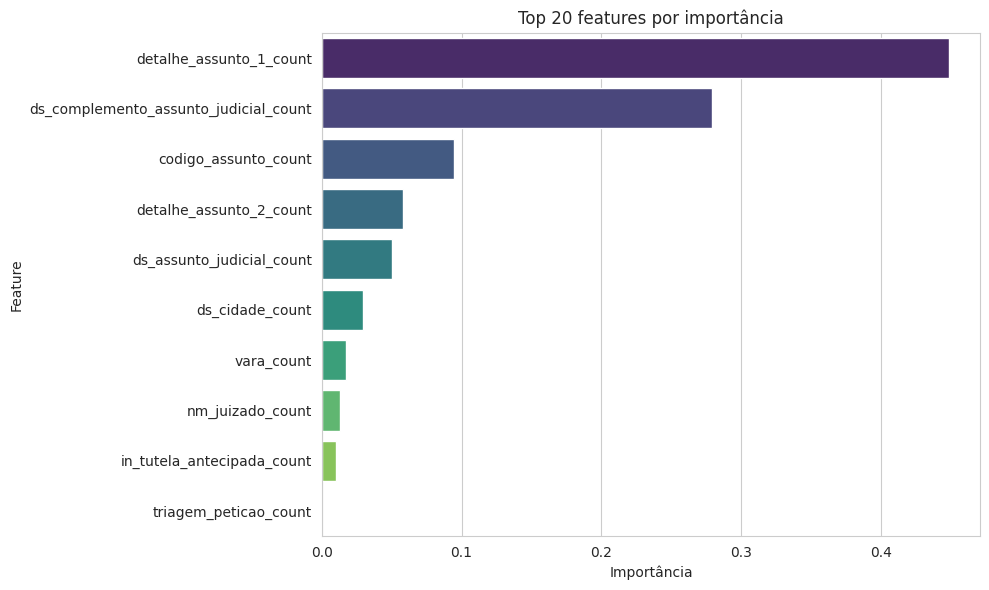

In [44]:
# gráficos de evolução e desempenho

evals_result = model.evals_result()
epochs = list(range(1, len(evals_result['validation_0']['logloss']) + 1))

plt.figure(figsize=(10, 5))
plt.plot(epochs, evals_result['validation_0']['logloss'], label='Treino logloss', marker='o')
plt.plot(epochs, evals_result['validation_1']['logloss'], label='Validação logloss', marker='o')
if 'error' in evals_result['validation_0']:
    plt.plot(epochs, evals_result['validation_0']['error'], label='Treino error', linestyle='--')
    plt.plot(epochs, evals_result['validation_1']['error'], label='Validação error', linestyle='--')
plt.xlabel('Época')
plt.ylabel('Valor')
plt.title('Curvas de aprendizado do XGBoost')
plt.legend()
plt.grid(True)
plt.show()

metrics_summary = {
    'Treino': compute_metrics(y_train, model.predict(X_train)),
    'Validação': compute_metrics(y_val, model.predict(X_val)),
    'Teste': compute_metrics(y_test, y_test_pred),
}
metrics_df = pd.DataFrame(metrics_summary).T
metrics_df.plot(kind='bar', figsize=(10, 6))
plt.title('Comparação de métricas por conjunto')
plt.ylim(0, 1)
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de confusão (teste)')
plt.xlabel('Predições')
plt.ylabel('Reais')
plt.show()

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_,
}).sort_values(by='importance', ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Top 20 features por importância')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Validação Cruzada (10-Fold)

Para uma avaliação mais robusta do modelo, vamos aplicar a validação cruzada com 10 folds estratificados. Isso ajuda a reduzir a variância da estimativa de desempenho do modelo, garantindo que cada fold mantenha a proporção das classes alvo, o que é especialmente útil para conjuntos de dados desbalanceados.

In [45]:
from sklearn.model_selection import StratifiedKFold

# Inicializar o StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Listas para armazenar as métricas de cada fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

print('Iniciando validação cruzada com 10 folds...')

# Iterar sobre cada fold
for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
    print(f'\n--- Fold {fold+1}/10 ---')
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Re-inicializar o modelo para cada fold
    fold_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric=['logloss', 'error'],
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )

    # Treinar o modelo no fold atual
    fold_model.fit(
        X_train_fold,
        y_train_fold,
        eval_set=[(X_train_fold, y_train_fold), (X_val_fold, y_val_fold)],
        verbose=False
    )

    # Fazer previsões no conjunto de validação do fold
    y_pred_fold = fold_model.predict(X_val_fold)

    # Calcular métricas e armazenar
    metrics = compute_metrics(y_val_fold, y_pred_fold)
    accuracy_scores.append(metrics['accuracy'])
    precision_scores.append(metrics['precision'])
    recall_scores.append(metrics['recall'])
    f1_scores.append(metrics['f1_score'])

    print(f'  Accuracy: {metrics["accuracy"]:.4f}')
    print(f'  Precision: {metrics["precision"]:.4f}')
    print(f'  Recall: {metrics["recall"]:.4f}')
    print(f'  F1-Score: {metrics["f1_score"]:.4f}')

print('\nValidação cruzada concluída.')

Iniciando validação cruzada com 10 folds...

--- Fold 1/10 ---
  Accuracy: 0.9149
  Precision: 0.8934
  Recall: 0.9451
  F1-Score: 0.9185

--- Fold 2/10 ---
  Accuracy: 0.9194
  Precision: 0.8999
  Recall: 0.9464
  F1-Score: 0.9225

--- Fold 3/10 ---
  Accuracy: 0.9227
  Precision: 0.9044
  Recall: 0.9478
  F1-Score: 0.9256

--- Fold 4/10 ---
  Accuracy: 0.9199
  Precision: 0.8979
  Recall: 0.9502
  F1-Score: 0.9233

--- Fold 5/10 ---
  Accuracy: 0.9148
  Precision: 0.8939
  Recall: 0.9441
  F1-Score: 0.9183

--- Fold 6/10 ---
  Accuracy: 0.9180
  Precision: 0.8994
  Recall: 0.9439
  F1-Score: 0.9211

--- Fold 7/10 ---
  Accuracy: 0.9150
  Precision: 0.8925
  Recall: 0.9465
  F1-Score: 0.9187

--- Fold 8/10 ---
  Accuracy: 0.9196
  Precision: 0.8991
  Recall: 0.9478
  F1-Score: 0.9228

--- Fold 9/10 ---
  Accuracy: 0.9147
  Precision: 0.8911
  Recall: 0.9477
  F1-Score: 0.9185

--- Fold 10/10 ---
  Accuracy: 0.9167
  Precision: 0.8965
  Recall: 0.9448
  F1-Score: 0.9200

Validação cruz


--- Métricas Médias da Validação Cruzada (10-Fold) ---
  Média Accuracy: 0.9176 (+/- 0.0026)
  Média Precision: 0.8968 (+/- 0.0039)
  Média Recall: 0.9464 (+/- 0.0019)
  Média F1-Score: 0.9209 (+/- 0.0024)


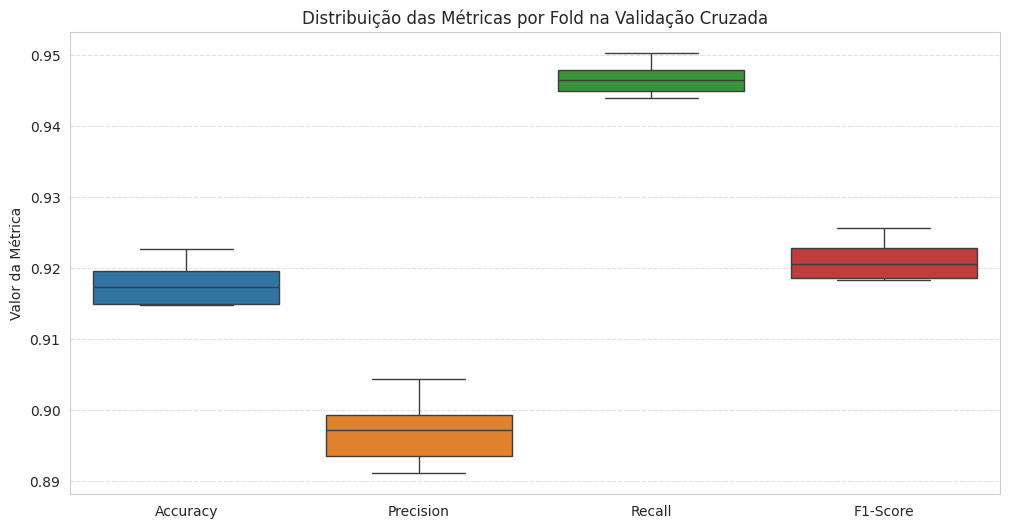

In [46]:
import numpy as np

# Exibir as métricas médias da validação cruzada
print(f'\n--- Métricas Médias da Validação Cruzada (10-Fold) ---')
print(f'  Média Accuracy: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})')
print(f'  Média Precision: {np.mean(precision_scores):.4f} (+/- {np.std(precision_scores):.4f})')
print(f'  Média Recall: {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})')
print(f'  Média F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})')

# Visualizar a distribuição das métricas por fold
metrics_df_cv = pd.DataFrame({
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
})

plt.figure(figsize=(12, 6))
sns.boxplot(data=metrics_df_cv)
plt.title('Distribuição das Métricas por Fold na Validação Cruzada')
plt.ylabel('Valor da Métrica')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

A validação cruzada com 10 folds só reforça a qualidade de classificação alcançada com o método XGBoost nesse dataset, alcançando métricas de qualidade muito boa a um custo computacional baixo no processamento, com avaliação de uma baixa quantidade de dados do processo (10 features foram apresentadas).